Installing relevant libraries.

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
crime_21 = pd.read_csv("C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2021.csv", usecols=["Longitude", "Latitude", "Crime type"])
crime_22 = pd.read_csv("C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2022.csv", usecols=["Longitude", "Latitude", "Crime type"])
crime_23 = pd.read_csv("C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2023.csv", usecols=["Longitude", "Latitude", "Crime type"])

# df_21 = pd.DataFrame(crime_21, usecols=["Longitude", "Latitude", "Crime Type"])
# df_22 = pd.DataFrame(crime_22, usecols=["Longitude", "Latitude", "Crime Type"])
# df_23 = pd.DataFrame(crime_23, usecols = ["Longitude", "Latitude", "Crime Type"])

print(crime_21.head())
print(crime_22.head())
print(crime_23.head())

   Longitude   Latitude                    Crime type
0  -1.501874  52.279611                   Other theft
1  -1.498624  52.272738                 Vehicle crime
2  -1.501874  52.279611  Violence and sexual offences
3  -1.499642  52.276068                      Burglary
4  -1.530402  52.294499         Anti-social behaviour
   Longitude   Latitude                    Crime type
0  -1.501874  52.279611                  Public order
1  -1.499558  52.275672  Violence and sexual offences
2  -1.530358  52.293096         Anti-social behaviour
3  -1.530358  52.293096     Criminal damage and arson
4  -1.530677  52.293421                         Drugs
   Longitude   Latitude                    Crime type
0  -1.501372  52.278584                 Vehicle crime
1  -1.499616  52.274459  Violence and sexual offences
2  -1.498516  52.277151                   Other theft
3  -1.498516  52.277151  Violence and sexual offences
4  -1.527475  52.293975         Anti-social behaviour


In [4]:
combined_df = pd.concat([crime_21, crime_22, crime_23], ignore_index=True)
combined_df.info()
combined_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17315 entries, 0 to 17314
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Longitude   17315 non-null  float64
 1   Latitude    17315 non-null  float64
 2   Crime type  17315 non-null  object 
dtypes: float64(2), object(1)
memory usage: 405.9+ KB


,Longitude,Latitude,Crime type
0,-1.501874,52.279611,Other theft
1,-1.498624,52.272738,Vehicle crime
2,-1.501874,52.279611,Violence and sexual offences
3,-1.499642,52.276068,Burglary
4,-1.530402,52.294499,Anti-social behaviour
...,...,...,...
17310,-1.510822,52.273670,Violence and sexual offences
17311,-1.532949,52.272519,Anti-social behaviour
17312,-1.528026,52.269667,Criminal damage and arson
17313,-1.531491,52.271875,Drugs


Creating Static Heatmap with geopandas and Matplot Lib.

Shows coordinate ranges and dots where crime data is.

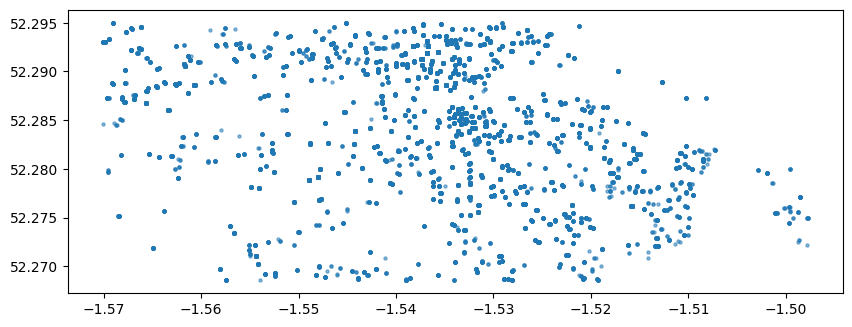

In [5]:
gdf = gpd.GeoDataFrame(combined_df, geometry=gpd.points_from_xy(combined_df.Longitude, combined_df.Latitude))#

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, markersize=5, alpha=0.5)  # Adjust markersize and alpha for better visualization
plt.show()

In [6]:
import folium
from folium.plugins import HeatMap

map_leamington = folium.Map(location=[52.272517,-1.562762], zoom_start=13)

# Assuming `data` is your DataFrame with 'latitude' and 'longitude'
heat_data = [[row['Latitude'], row['Longitude']] for index, row in combined_df.iterrows()]

# Add HeatMap layer to the map
HeatMap(heat_data).add_to(map_leamington)

# Save to HTML or display
map_leamington.save('leamington_crime_heatmap.html')
# or display in a Jupyter notebook
# map_leamington

Layering a heatmap showing public space data in Leamington Spa over a map of Leamington Spa. 

In [7]:
places = "C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\public_spaces_data_350.csv"
places_df = pd.read_csv(places, usecols=["Latitude", "Longitude", "Place Name"])

places_df.head()
places_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Place Name  321 non-null    object 
 1   Latitude    321 non-null    float64
 2   Longitude   321 non-null    float64
dtypes: float64(2), object(1)
memory usage: 7.6+ KB


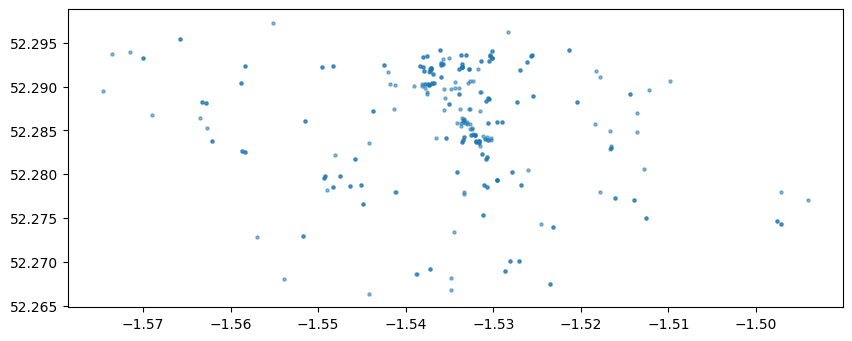

In [8]:
gdf = gpd.GeoDataFrame(places_df, geometry=gpd.points_from_xy(places_df.Longitude, places_df.Latitude))

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, markersize=5, alpha=0.5)  # Adjust markersize and alpha for better visualization
plt.show()

In [9]:
map_leamington = folium.Map(location=[52.272517,-1.562762], zoom_start=13)

# Assuming `data` is your DataFrame with 'latitude' and 'longitude'
heat_data = [[row['Latitude'], row['Longitude']] for index, row in places_df.iterrows()]

# Add HeatMap layer to the map
HeatMap(heat_data).add_to(map_leamington)

# Save to HTML or display
map_leamington.save('leamington_places_heatmap.html')

Heatmaps suggest that the more public spaces there are, the more crimes there are. 

This suggests that more public spaces could imply more crimes and therefore more unsafe routes, however subjectively people feel safer when there are public spaces around. 

Need to measure the severity of crimes of each area, as crimes could be less sever e.g. shoplifitng, rather than assault. 

In [10]:
# Mapping each crime type to a severity score. 

crime_severity_scores = {
    "Drugs" : 2,
    "Shoplifting" : 2,
    "Burglary" : 5,
    "Theft from the person" : 8,
    "Possession of weapons" : 9,
    "Violence and sexual offences" : 10,
    "Criminal damage and arson" : 7,
    "Vehicle crime" : 4,
    "Bicycle theft " : 2,
    "Other theft" : 1,
    "Public order" : 1,
    "Robbery" : 5, 
    "Anti-social behaviour" : 5,
    "Other crime" : 1
}

In [11]:
# Function to add a crime severity score to each row. 
def add_crime_severity(crime_data, crime_severity_scores):
    
    # Add severity score column to each row
    crime_data['Severity Score'] = crime_data['Crime type'].map(crime_severity_scores)

    return crime_data

In [12]:
updated_df = add_crime_severity(combined_df,crime_severity_scores)

updated_df

,Longitude,Latitude,Crime type,Severity Score
0,-1.501874,52.279611,Other theft,1.0
1,-1.498624,52.272738,Vehicle crime,4.0
2,-1.501874,52.279611,Violence and sexual offences,10.0
3,-1.499642,52.276068,Burglary,5.0
4,-1.530402,52.294499,Anti-social behaviour,5.0
...,...,...,...,...
17310,-1.510822,52.273670,Violence and sexual offences,10.0
17311,-1.532949,52.272519,Anti-social behaviour,5.0
17312,-1.528026,52.269667,Criminal damage and arson,7.0
17313,-1.531491,52.271875,Drugs,2.0


In [13]:
updated_df = updated_df.dropna(subset=['Latitude', 'Longitude', 'Severity Score'])

# Create a list of data points: [latitude, longitude, severity]
heat_data = [[row['Latitude'], row['Longitude'], row['Severity Score']] for index, row in updated_df.iterrows()]

# Create a map centered around an average or specific location
map = folium.Map(location=[52.272517,-1.562762], zoom_start=13)

# Add a HeatMap layer to the map
HeatMap(heat_data).add_to(map)

# Save to HTML or display
map.save('leamington_severity_heatmap.html')

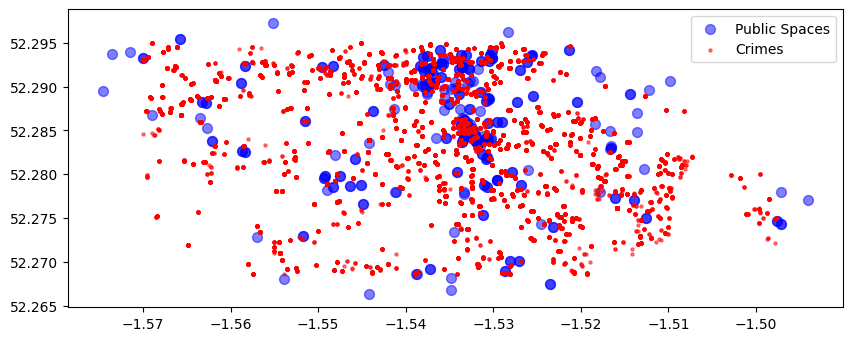

In [14]:
# import geopandas as gpd
# import matplotlib.pyplot as plt

# # Assuming 'public_spaces' and 'crimes_combined' are your DataFrame names for public spaces and crimes respectively.

# Create GeoDataFrames
gdf_public_spaces = gpd.GeoDataFrame(places_df, geometry=gpd.points_from_xy(places_df.Longitude, places_df.Latitude))
gdf_crimes = gpd.GeoDataFrame(combined_df, geometry=gpd.points_from_xy(combined_df.Longitude, combined_df.Latitude))

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))
gdf_public_spaces.plot(ax=ax, color='blue', markersize=50, label='Public Spaces', alpha=0.5)  # Public spaces in blue
gdf_crimes.plot(ax=ax, color='red', markersize=5, label='Crimes', alpha=0.5)  # Crimes in red

# Legend
plt.legend()

# Display
plt.show()


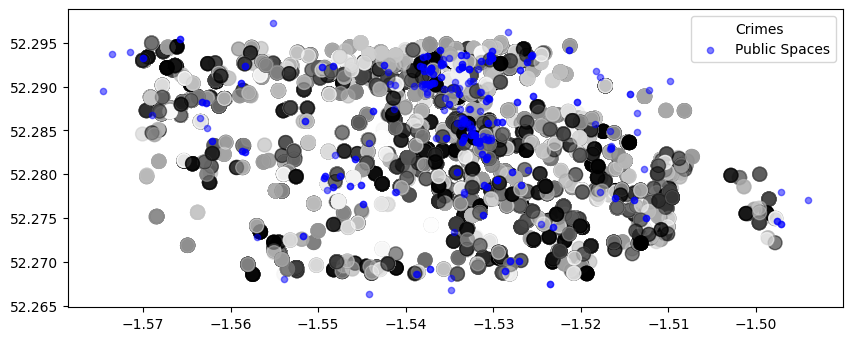

In [34]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Assuming places_df and combined_df are your public spaces and crimes DataFrames, respectively,
# and combined_df includes a 'Severity' column.

# Prepare GeoDataFrames
gdf_public_spaces = gpd.GeoDataFrame(places_df, geometry=gpd.points_from_xy(places_df.Longitude, places_df.Latitude))
gdf_crimes = gpd.GeoDataFrame(updated_df, geometry=gpd.points_from_xy(updated_df.Longitude, updated_df.Latitude))

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))
gdf_crimes.plot(ax=ax, column='Severity Score', cmap='Greys', markersize=100, alpha=0.5, label='Crimes')  # Crimes colored by severity
gdf_public_spaces.plot(ax=ax, color='blue', markersize=20, alpha=0.5, label='Public Spaces')  # Public spaces in blue

plt.legend()
plt.show()


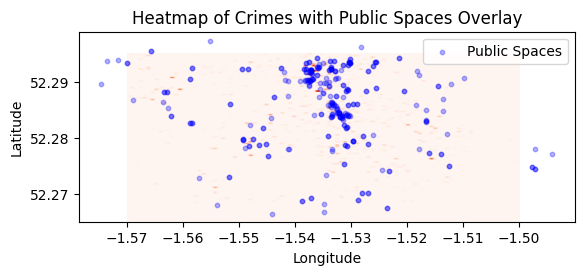

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming you have a DataFrame 'crimes_df' with 'Latitude', 'Longitude', and 'Severity'
# And a DataFrame 'public_spaces_df' with 'Latitude' and 'Longitude'

# Create a 2D histogram (heatmap) of the crime data
# Adjust the bins and range as needed to fit your data
heatmap, xedges, yedges = np.histogram2d(updated_df['Longitude'], updated_df['Latitude'], bins=100, 
                                         range=[[-1.57, -1.5], [52.265, 52.295]])
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

# Plot the heatmap
plt.imshow(heatmap.T, extent=extent, origin='lower', cmap='Reds', alpha=1)

# Overlay the public spaces
plt.scatter(places_df['Longitude'], places_df['Latitude'], 
            alpha=0.3, c='blue', s=10, label='Public Spaces')  # Adjust alpha, color, and size as needed

# Additional plot formatting
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.title('Heatmap of Crimes with Public Spaces Overlay')
plt.show()
